# Assignment 6 — Comparing Two Style Transfer Techniques on the Same Image

**Objective:** Take one photograph and restyle it using:
1. a pretrained **CycleGAN** generator
2. **VGG19 Neural Style Transfer**

## 1. Environment setup

In [13]:
import os
import sys
import urllib.request
import subprocess
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
Device: cuda


## 2. Load the content photograph

The notebook downloads a sample landscape photo automatically. You can replace it with your own image by uploading one in the optional block.

Content image size: (640, 480)


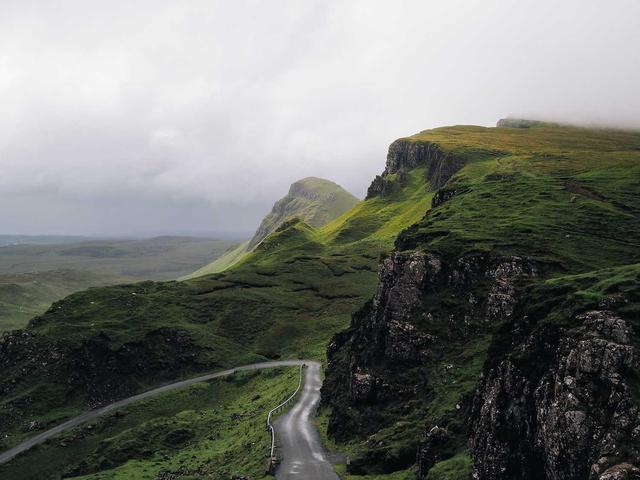

In [14]:
def download_file(url, save_path):
    try:
        urllib.request.urlretrieve(url, save_path)
        return True
    except Exception as e:
        print("Download failed:", e)
        return False

content_urls = [
    "https://picsum.photos/id/1018/640/480",
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
]

content_path = "/content/content_photo.jpg"

downloaded = False
for url in content_urls:
    if download_file(url, content_path):
        downloaded = True
        break

if not downloaded:
    raise RuntimeError("Could not download the sample image. Use the upload cell below.")

content_image = Image.open(content_path).convert("RGB")

print("Content image size:", content_image.size)
display(content_image)


### Optional: use your own image

Run this cell instead of the previous download cell if you want to use your own photograph.

In [15]:
# from google.colab import files
# uploaded = files.upload()
# content_path = list(uploaded.keys())[0]
# content_image = Image.open(content_path).convert("RGB")
# display(content_image)


## 3. Method 1 — Pretrained CycleGAN

CycleGAN performs image-to-image translation with a pretrained generator. The official repository provides a `style_monet` model trained for landscape-photo to Monet-style translation.

In [16]:
repo_dir = "/content/cyclegan_repo"

if not os.path.exists(repo_dir):
    subprocess.run(
        ["git", "clone", "-q", "https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git", repo_dir],
        check=True
    )

if repo_dir not in sys.path:
    sys.path.append(repo_dir)

from models.networks import define_G

print("CycleGAN repository ready")


CycleGAN repository ready


In [17]:
weights_path = "/content/style_monet.pth"
weights_url = "https://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth"

if not os.path.exists(weights_path):
    print("Downloading CycleGAN checkpoint...")
    if not download_file(weights_url, weights_path):
        raise RuntimeError("Could not download the CycleGAN checkpoint.")

file_size = os.path.getsize(weights_path)
print("Checkpoint size:", file_size, "bytes")

if file_size < 10_000_000:
    raise RuntimeError("The CycleGAN checkpoint did not download correctly.")


Checkpoint size: 45575747 bytes


In [18]:
cyclegan_generator = define_G(
    input_nc=3,
    output_nc=3,
    ngf=64,
    netG="resnet_9blocks",
    norm="instance",
    use_dropout=False,
    init_type="normal",
    init_gain=0.02
)

raw_state_dict = torch.load(weights_path, map_location=device)

cleaned_state_dict = {}

for key, value in raw_state_dict.items():
    key = key.replace("module.", "")

    if "running_mean" not in key and "running_var" not in key and "num_batches_tracked" not in key:
        cleaned_state_dict[key] = value

cyclegan_generator.load_state_dict(cleaned_state_dict, strict=False)

cyclegan_generator = cyclegan_generator.to(device).eval()

print("CycleGAN generator ready")

CycleGAN generator ready


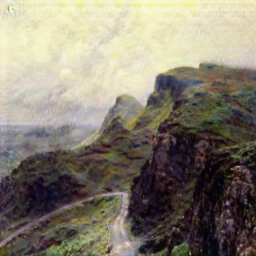

In [19]:
import torchvision.transforms as T

cyclegan_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

def run_cyclegan(pil_image):
    x = cyclegan_transform(pil_image).unsqueeze(0).to(device)

    with torch.no_grad():
        y = cyclegan_generator(x)

    y = y.squeeze(0).cpu()
    y = (y * 0.5 + 0.5).clamp(0, 1)

    return T.ToPILImage()(y)

cyclegan_result = run_cyclegan(content_image)
display(cyclegan_result)


## 4. Method 2 — VGG19 Neural Style Transfer

Download failed: HTTP Error 403: Forbidden


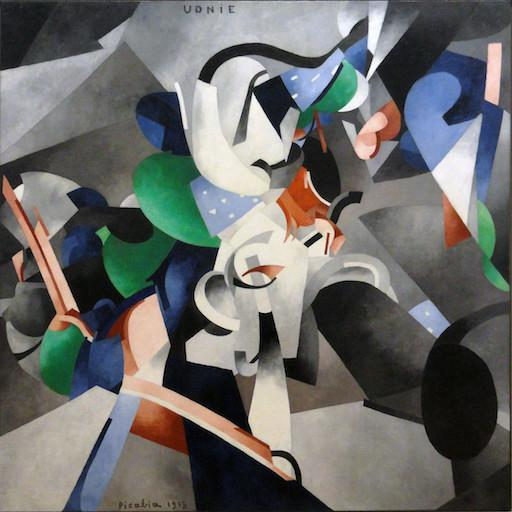

In [20]:
from torchvision.models import vgg19, VGG19_Weights
import torch.nn.functional as F

style_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/640px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg",
    "https://raw.githubusercontent.com/pytorch/examples/main/fast_neural_style/images/style-images/udnie.jpg"
]

style_path = "/content/style_painting.jpg"

downloaded = False
for url in style_urls:
    if download_file(url, style_path):
        downloaded = True
        break

if not downloaded:
    raise RuntimeError("Could not download the style image.")

style_image = Image.open(style_path).convert("RGB")
display(style_image)


In [21]:
nst_size = 256

transform_nst = T.Compose([
    T.Resize((nst_size, nst_size)),
    T.ToTensor()
])

def load_image_for_nst(pil_image):
    return transform_nst(pil_image).unsqueeze(0).to(device)

content_tensor = load_image_for_nst(content_image)
style_tensor = load_image_for_nst(style_image)

vgg_features = vgg19(weights=VGG19_Weights.DEFAULT).features.to(device).eval()

for parameter in vgg_features.parameters():
    parameter.requires_grad = False

mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def normalize_for_vgg(x):
    return (x - mean) / std

print("VGG19 ready")


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 99.8MB/s]


VGG19 ready


In [22]:
content_layer = "21"
style_layers = ["0", "5", "10", "19", "28"]

def extract_features(image_tensor):
    x = normalize_for_vgg(image_tensor)

    features = {}
    for name, layer in vgg_features._modules.items():
        x = layer(x)

        if name == content_layer:
            features["content"] = x

        if name in style_layers:
            features[f"style_{name}"] = x

    return features

def gram_matrix(feature):
    _, channels, height, width = feature.shape
    feature = feature.reshape(channels, height * width)
    return (feature @ feature.t()) / (channels * height * width)

with torch.no_grad():
    content_features = extract_features(content_tensor)
    style_features = extract_features(style_tensor)

style_grams = {
    name: gram_matrix(feature)
    for name, feature in style_features.items()
}

print("Content and style features extracted")


Content and style features extracted


Step   0 | Content loss: 0.0000 | Style loss: 0.000247
Step  50 | Content loss: 10.0587 | Style loss: 0.000017
Step 100 | Content loss: 9.6846 | Style loss: 0.000012
Step 150 | Content loss: 8.7407 | Style loss: 0.000012
Step 199 | Content loss: 8.3774 | Style loss: 0.000013


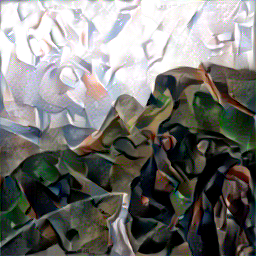

In [23]:
generated = content_tensor.clone().requires_grad_(True)

optimizer = torch.optim.Adam([generated], lr=0.03)

content_weight = 1.0
style_weight = 1e6
steps = 200

for step in range(steps):
    optimizer.zero_grad()

    current_features = extract_features(generated.clamp(0, 1))

    content_loss = F.mse_loss(
        current_features["content"],
        content_features["content"]
    )

    style_loss = 0.0

    for name in style_grams:
        current_gram = gram_matrix(current_features[name])
        style_loss = style_loss + F.mse_loss(
            current_gram,
            style_grams[name]
        )

    total_loss = content_weight * content_loss + style_weight * style_loss

    total_loss.backward()
    optimizer.step()

    if step % 50 == 0 or step == steps - 1:
        print(
            f"Step {step:3d} | "
            f"Content loss: {content_loss.item():.4f} | "
            f"Style loss: {style_loss.item():.6f}"
        )

nst_result_tensor = generated.detach().clamp(0, 1).cpu().squeeze(0)
nst_result = T.ToPILImage()(nst_result_tensor)

display(nst_result)


## 5. Side-by-side comparison

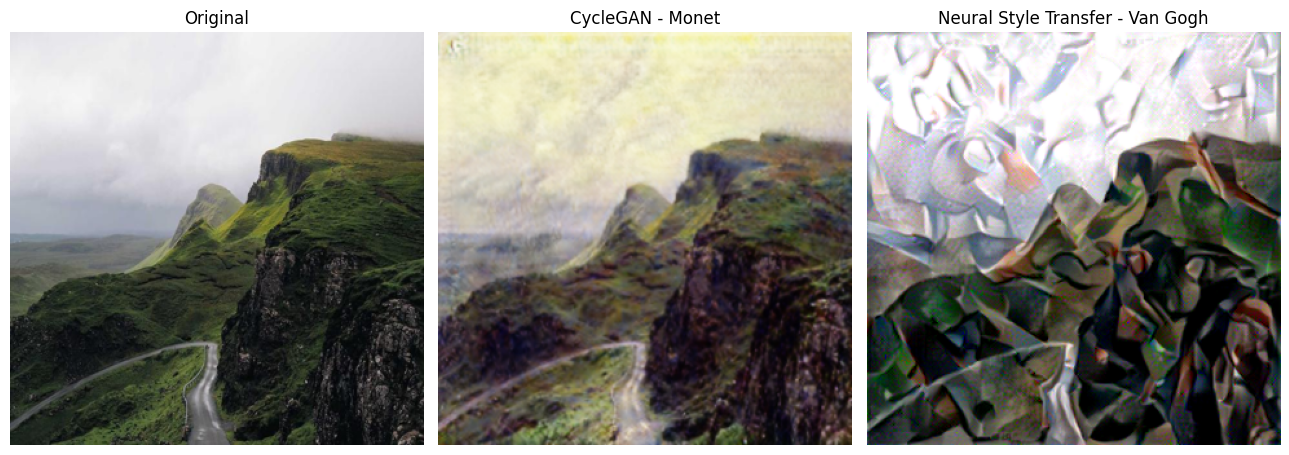

In [24]:
display_size = (320, 320)

images = [
    (content_image.resize(display_size), "Original"),
    (cyclegan_result.resize(display_size), "CycleGAN - Monet"),
    (nst_result.resize(display_size), "Neural Style Transfer - Van Gogh")
]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, (img, title) in zip(axes, images):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6. Save the outputs

In [25]:
content_image.save("/content/output_original.png")
cyclegan_result.save("/content/output_cyclegan.png")
nst_result.save("/content/output_neural_style_transfer.png")

print("Saved:")
print("/content/output_original.png")
print("/content/output_cyclegan.png")
print("/content/output_neural_style_transfer.png")


Saved:
/content/output_original.png
/content/output_cyclegan.png
/content/output_neural_style_transfer.png


## Observation

The original image shows a natural mountain landscape with green hills, rocky areas, a road, and a cloudy sky.

The CycleGAN output changes the image into a Monet-like artistic style. The main objects and overall structure of the original image are still clearly visible, while the colours and textures become softer and more painterly.

The Neural Style Transfer output produces a stronger artistic effect. The original scene is still visible, but the image contains more noticeable textures, colour variations, and brush-like patterns inspired by the style image.

## Result

The experiment successfully compared two different style transfer techniques on the same image.

CycleGAN mainly changed the overall appearance and style while preserving the original content and structure of the scene.

Neural Style Transfer produced a stronger and more noticeable artistic transformation by applying the texture and visual characteristics of the reference painting.

Therefore, the two methods produced different results from the same input image, showing how different style transfer techniques affect content, colour, texture, and artistic appearance.